In [1]:
%cd /home/dani/projects/mixture/

/home/dani/projects/mixture


In [2]:
from load import load_aggregate_datamed, load_datamed
from input import get_params
import numpy as np
import copy
import torch.nn as nn
from tqdm import tqdm
import time
import torch
from Experiment import Experiment, prepare_experiments
from Utils.MMD_utils import init_params
from torch.distributions.multivariate_normal import MultivariateNormal
import torch
from torch import optim
import torch.optim.lr_scheduler as lr_sched
#from Core.train_node import Trainer
from Core.node import NeuralODE

/home/dani/projects/mixture/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
options, params_data, params_optim, params_uq, params_node = get_params()
exps = prepare_experiments(params_data, params_optim, params_uq, params_node, options)

[INFO] Using cached run folder → Results_TimeSeries/run2
[INFO] Saved generated data summary to /home/dani/projects/mixture/Results_TimeSeries/run2/data.csv


In [4]:
combo, data, gamma = exps["exp_1"].values()
data2 = torch.tensor(np.array(data), dtype=torch.float32)
print(data2.shape)

torch.Size([11, 5000, 2])


In [5]:
# Setup time grids
t_i = torch.linspace(0.0, combo["T"], combo["t_steps"])
t_grid = torch.linspace(0.0, combo["T"], int(combo["T"] / combo["dt"]) + 1)
d = options['fixed_params']['d']
K = 3 #combo["K"]

In [6]:
local_weights, means, covs = init_params(data2.reshape(-1, d), K=K)

In [7]:
# observation tensor (T, 1, K)
t_i = torch.linspace(0.0, combo["T"], combo["t_steps"], device=device)
t_grid = torch.linspace(0.0, combo["T"], int(combo["T"] / combo["dt"]) + 1, device=device)

In [ ]:
class LogLikelihoodLoss(nn.Module):
    """
    Log-likelihood loss for mixture of Gaussians.
    
    Implements: -∑_{n=1}^N log ∑_{s=1}^K α_s(t_n;θ) φ(x_n | m_s, Σ_s)
    """
    
    def __init__(self, K, state_dim, device, eps=1e-8):
        """
        Initialize log-likelihood loss.
        
        Args:
            K: Number of mixture components
            state_dim: Dimensionality of state space
            device: Device for computations
            eps: Small constant for numerical stability
        """
        super().__init__()
        self.K = K
        self.state_dim = state_dim
        self.device = device
        self.eps = eps
        
    def forward(self, x_pred, x_obs, means, covariances):
        """
        Compute negative log-likelihood loss.
        
        Args:
            x_pred: Predicted trajectories [n_timesteps, batch_size, state_dim]
            x_obs: Observed trajectories [n_timesteps, batch_size, state_dim] 
            t_eval: Evaluation times [n_timesteps]
        
        Returns:
            Negative log-likelihood loss
        """
        all_log_probs = []  # shape [N, K]

        for k in range(self.K):
            mean_k = means[k]
            cov_k = covariances[k]
            mvn = MultivariateNormal(mean_k, cov_k)
            log_prob_k = mvn.log_prob(x_obs)  # shape [N]
            log_alpha_k = torch.log(x_pred[..., k] + self.eps)  # shape [N]
            all_log_probs.append(log_alpha_k + log_prob_k)

        # Stack into [N, K]
        all_log_probs = torch.stack(all_log_probs, dim=-1)

        # Log-sum-exp across K, then sum across N
        total_log_likelihood = torch.logsumexp(all_log_probs, dim=-1).mean() # TODO.mean(axis=1).sum()

        # Negative log-likelihood
        return -total_log_likelihood


class Trainer:
    """
    Trainer class for optimizing Neural ODE models with log-likelihood loss.
    
    Minimizes negative log-likelihood between predicted and observed trajectories.
    """
    
    def __init__(self, model, optimizer, scheduler, device, loss_str="LogLikelihood", 
                 reg_lambda=0.0, print_freq=10, 
                 tol=1e-6, tolrel=1e-4, patience=200, K=3, d=2, lr=1e-3):
        """
        Initialize trainer.
        
        Args:
            model: Neural ODE model
            optimizer: PyTorch optimizer
            scheduler: Learning rate scheduler  
            device: Training device
            loss_str: Loss function ("MSE", "L1", "LogLikelihood")
            reg_lambda: L2 regularization coefficient
            print_freq: Print frequency for training progress
            tol: Absolute tolerance for early stopping
            tolrel: Relative tolerance for early stopping
            patience: Epochs to wait before early stopping
            K: Number of mixture components (for LogLikelihood loss)
        """
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.K = K
        self.d = d

        # Means: [K, state_dim]
        self.means = nn.Parameter(torch.tensor(means, dtype=torch.float32), requires_grad=False)

        # Covariances: Use Cholesky decomposition for positive definiteness
        # Shape: [K, state_dim, state_dim]
        self.covs = nn.Parameter(torch.tensor(covs, dtype=torch.float32), requires_grad=False)
        
        # Configure loss function
        if loss_str is None or loss_str == 'MSE':
            self.loss_func = nn.MSELoss()
        elif loss_str == 'L1':
            self.loss_func = nn.L1Loss()
        elif isinstance(loss_str, LogLikelihoodLoss):
            # Determine state dimension from model
            self.loss_func = loss_str
        else:
            raise ValueError(f"Unknown loss function: {loss_str}")
        
        self.reg_lambda = reg_lambda
        self.print_freq = print_freq
        self.tol = tol
        self.tolrel = tolrel
        self.patience = patience
        
        self.best_loss = float('inf')
        self.best_state = None
        self.loss_history = []
        self.cov_reg = 1e-5
        self.eps = 1e-8  # for numerical stability in log
        self.lr = lr

    
    def _compute_regularization(self):
        """Compute L2 regularization terms."""
        reg_loss = 0.0
        # Regularize model parameters
        #reg_loss += self.reg_lambda * sum(torch.sum(param ** 2) for param in self.model.parameters())
        # Regularize mixture parameters if using log-likelihood
        return reg_loss
    
    def _compute_total_loss(self, x_pred, x_obs, t_eval=None):
        """Compute total loss including regularization."""
        loss = self.loss_func(x_pred, x_obs)
        
        reg_loss = self._compute_regularization()
        return loss + reg_loss
    
    def _should_stop_early(self, current_loss, prev_loss, patience_counter):
        """Check early stopping conditions."""
        # Absolute tolerance
        if current_loss < self.tol:
            return True, f"absolute tolerance ({self.tol})"
        
        # Patience exceeded
        if patience_counter >= self.patience:
            return True, f"no improvement in {self.patience} epochs"
        
        # Relative tolerance
        if prev_loss is not None:
            abs_diff = abs(current_loss - prev_loss)
            rel_diff = abs_diff / (abs(prev_loss) + 1e-12)
            if rel_diff < self.tolrel:
                return True, f"relative tolerance ({self.tolrel})"
        
        return False, None
    
    def e_step(self, x_obs, t_eval):
        T, B, D = x_obs.shape  # batch size
        initial_state_batch = torch.zeros(B, K)
        with torch.no_grad():
            a = self.model(initial_state_batch, eval_times=t_eval)  # [B, T, K]
            a = a.clamp(min=1e-8)

        log_prob = torch.empty(T, B, self.K, device=self.device)
        for k in range(self.K):
            # ensure covariance is SPD by adding diag jitter
            cov_k = self.covs[k] + self.cov_reg * torch.eye(self.d, device=self.device)
            mvn = MultivariateNormal(loc=self.means[k], covariance_matrix=cov_k)
            log_prob[..., k] = mvn.log_prob(x_obs) # [B]

        # 3) compute log_joint: log(a_k) + log p_k
        log_a = torch.log(a + self.eps)  # [B, K]
        log_joint = log_a + log_prob  # [B, K]

        # 4) normalize in log-space -> responsibilities gamma [B, K]
        log_sum = torch.logsumexp(log_joint, dim=2, keepdim=True)  # [B, 1]
        log_gamma = log_joint - log_sum  # [B, K]
        gamma = torch.exp(log_gamma)  # [B, K]; rows sum to 1
        return gamma, log_joint
    
    def m_step_gaussians(self, x: torch.Tensor, gamma: torch.Tensor):
        """Closed-form updates of Gaussian parameters using responsibilities gamma"""
        # x: [N,B,D], gamma: [N,B,K]
        gamma = gamma.reshape(-1, self.K)  # [N*B, K]
        x = x.reshape(-1, self.d)  # [N*B, D
        Nk = gamma.sum(dim=0)  # [K] sums over i
        Nk_safe = Nk.clone().clamp_min(1e-8)  # avoid division by zero

        # Update means: mu_k = (1 / N_k) sum_i gamma_{ik} x_i
        mu_new = (gamma.transpose(1,0) @ x) / Nk_safe.unsqueeze(1)  # [K, D]

        # Update covariances:
        covs_new = torch.zeros(self.K, self.d, self.d, device=self.device)
        for k in range(self.K):
            diff = x - mu_new[k].unsqueeze(0)  # [N, D]
            # Weighted empirical covariance:
            w = gamma[:, k].unsqueeze(1)  # [N,1]
            # sum_i gamma_{ik} * diff_i^T diff_i  -> [D,D]
            cov_k = (diff * w).t() @ diff  # [D, D]
            cov_k = cov_k / Nk_safe[k]
            # regularize
            cov_k += self.cov_reg * torch.eye(self.d, device=self.device)
            covs_new[k] = cov_k

        self.means = mu_new.detach()
        self.covs = covs_new.detach()
        

    def m_step_theta(self, x: torch.Tensor, t: torch.Tensor, gamma: torch.Tensor, steps: int = 20, batch_size: int = 32):
        """Optimize mixing network parameters theta by minimizing:
           L(theta) = - sum_i sum_k gamma_{ik} log a_k(t_i; theta)
           We'll do several gradient steps with Adam.
        """
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        N = x.shape[0]

        n_samples = x.shape[1]
        x0 = torch.zeros(batch_size, K)
        progress_bar = tqdm(range(steps), desc="Training")
        for _ in progress_bar:
            indices = np.random.choice(n_samples, size=batch_size, replace=False)
            gamma_det_i = gamma[:,indices, :]
            optimizer.zero_grad()
            a = self.model(x0, t) 
            a = a.clamp(min=self.eps)
            log_a = torch.log(a)
            loss = -(gamma_det_i * log_a).mean(axis=(0,1)).sum()  # average per point
            loss.backward()
            optimizer.step()
            progress_bar.set_postfix(loss_neuralODE=f"{loss.item():.5f}")
    
    def train(self, t_train, x_obs, initial_state, batch_size=32, max_epochs=5, m_steps=100, shuffle=True):
        """
        Train the Neural ODE model using mini-batch learning.
        
        Args:
            t_train: Time points tensor [n_timesteps]
            x_obs: Observed trajectory [n_timesteps, n_samples, state_dim]
            initial_state: Initial state [n_samples, state_dim]
            batch_size: Size of mini-batches (default: 32)
            shuffle: Whether to shuffle data between epochs (default: True)
        
        Returns:
            Best training loss
        """
        self.model.train()
        
        # Move data to device
        t_train = t_train.to(self.device)
        x_obs = x_obs.to(self.device)
        initial_state = initial_state.to(self.device)
        
        n_samples = x_obs.shape[1]  # Number of samples/trajectories
        n_batches = (n_samples + batch_size - 1) // batch_size  # Ceiling division
        
        
        for epoch in range(max_epochs):
            with torch.no_grad():
                gamma, log_joint = self.e_step(x_obs, t_train,)
                
                loss = -torch.logsumexp(log_joint, dim=2).mean().item()  # total loglik
                #loss = self._compute_total_loss(a, x_obs)
                print(f"Iter {epoch}: total negative log-likelihood = {loss:.5f}")

                # M-step for Gaussians (closed form)
                self.m_step_gaussians(x_obs, gamma)

            # M-step for theta (optimize neural net)
            self.m_step_theta(x_obs, t_train, gamma, steps=m_steps, batch_size=batch_size)

        
        # Load best model state
        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)
        
        print(f"Total samples: {n_samples}, Batch size: {batch_size}, Batches per epoch: {n_batches}")
        
        return self.best_loss

In [9]:
loss = LogLikelihoodLoss(K, d, device)
model = NeuralODE(
        K, combo["hidden_dim"],
        non_linearity = 'tanh', #combo['non_linearity'],
        N_layers      = 1, #combo['N_layers'],
        T             = combo["T"],
        step_size     = combo["dt"],
        method        = 'euler' #combo["method"]
    ).to(device)
print(">> Using standard Neural ODE with post-hoc normalization")

>> Using standard Neural ODE with post-hoc normalization


In [10]:
opt  = optim.Adam(list(model.parameters()) + list(loss.parameters()), lr=1e-4)
sch  = lr_sched.ReduceLROnPlateau(opt, mode="min",
                                factor=0.5, patience=50)
sch = None
trainer = Trainer(model, opt, sch, device,
                loss_str     = loss, #combo["loss_func"],
                reg_lambda   = combo["lambda_node"],
                print_freq   = 1, #combo["print_freq"],
                K=K,
                d=d,
                tol          = combo["tol_abs"],
                lr=1e-4,
                tolrel       = combo["tol_rel"])


trainer.train(t_i, data2, data2[0], batch_size=128, max_epochs=10, m_steps=50)
loss_history = trainer.loss_history

Iter 0: total negative log-likelihood = 7.67650


Training: 100%|██████████| 50/50 [00:03<00:00, 13.79it/s, loss_neuralODE=0.23337]


Iter 1: total negative log-likelihood = 4.22685


Training: 100%|██████████| 50/50 [00:03<00:00, 14.27it/s, loss_neuralODE=0.95710]


Iter 2: total negative log-likelihood = 4.34191


...

Iter 8: total negative log-likelihood = 4.01445


Training: 100%|██████████| 50/50 [00:03<00:00, 13.81it/s, loss_neuralODE=0.19975]


Iter 9: total negative log-likelihood = 4.04405


Training: 100%|██████████| 50/50 [00:03<00:00, 14.19it/s, loss_neuralODE=0.16128]

Total samples: 5000, Batch size: 128, Batches per epoch: 40


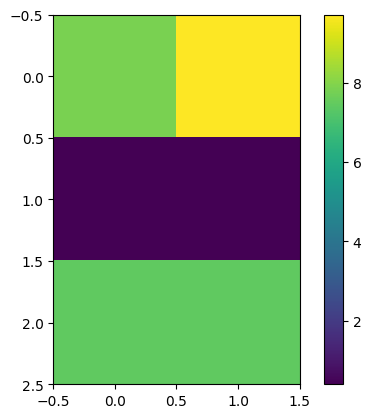

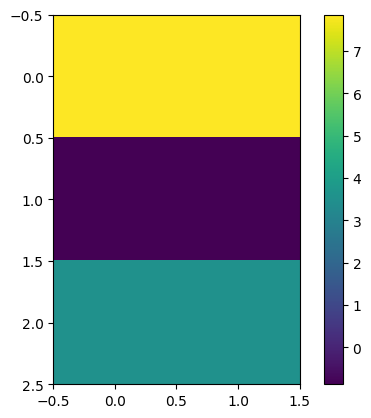

In [11]:
import matplotlib.pyplot as plt
plt.imshow(trainer.means.detach().cpu().numpy()); plt.colorbar()
plt.show()
plt.imshow(means)
#plt.imshow(loss.get_covariances().detach().cpu().numpy())
plt.colorbar()
plt.show()